In [1]:
pip install node2vec

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

from node2vec import Node2Vec
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

In [3]:
TRAIN_PATH    = "../outputs/clean_train.parquet"
TEST_PATH     = "../outputs/clean_test.parquet"
CLEAN_PATH    = "../outputs/clean_all.parquet"
GRAPH_PATH    = "../outputs/graphs.pkl"
BASELINE_PATH = "../outputs/models/baseline_model.pkl"
OUT_DIR       = "../outputs/models"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)
df    = pd.read_parquet(CLEAN_PATH)

# Load graphs
with open(GRAPH_PATH, 'rb') as f:
    graphs = pickle.load(f)
G = graphs['main']

# Load baseline for comparison
with open(BASELINE_PATH, 'rb') as f:
    baseline = pickle.load(f)

In [5]:
print(f"Train shape  : {train.shape}")
print(f"Test shape   : {test.shape}")
print(f"Graph        : {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges")
print(f"\nBaseline to beat:")
print(f"  MAE        : {baseline['mae']} min")
print(f"  Within 15% : {baseline['within_15pct']}%")

Train shape  : (103126, 29)
Test shape   : (39376, 29)
Graph        : 1,657 nodes  2,783 edges

Baseline to beat:
  MAE        : 55.45 min
  Within 15% : 50.46%


In [34]:
print("Training node2vec embeddings on main graph...")
print("Parameters explanation:")
print("  dimensions  = 64  — each hub gets a 32-dim vector")
print("  walk_length = 20  — each random walk is 20 hops long")
print("  num_walks   = 200 — 200 walks per node")
print("  p = 1, q = 2      — biased toward exploring new nodes (DFS-like) captures global network position")

node2vec = Node2Vec(
    G,
    dimensions  = 64,
    walk_length = 20,
    num_walks   = 200,
    p           = 1,
    q           = 2,
    weight_key  = 'weight',
    workers     = 4,
    quiet       = False
)

model_n2v = node2vec.fit(
    window    = 10,
    min_count = 1,
    batch_words = 4
)

print("node2vec embeddings trained")
print(f"  Vocabulary size : {len(model_n2v.wv):,} nodes")
print(f"  Embedding dim   : {model_n2v.wv.vector_size}")

Training node2vec embeddings on main graph...
Parameters explanation:
  dimensions  = 32  — each hub gets a 32-dim vector
  walk_length = 20  — each random walk is 20 hops long
  num_walks   = 100 — 100 walks per node
  p = 1, q = 2      — biased toward exploring new nodes (DFS-like) captures global network position


Computing transition probabilities:   0%|          | 0/1657 [00:00<?, ?it/s]

node2vec embeddings trained
  Vocabulary size : 1,657 nodes
  Embedding dim   : 64


In [35]:
gurgaon_code = df[df['source_name'].str.contains('Gurgaon_Bilaspur_HB', na=False)]['source_center'].iloc[0]
guwahati_code = df[df['source_name'].str.contains('Guwahati_Hub', na=False)]['source_center'].iloc[0]

In [36]:
print(f"\nMost similar hubs to Gurgaon_Bilaspur_HB:")
similar = model_n2v.wv.most_similar(gurgaon_code, topn=5)
name_lookup = {}
for _, row in df.groupby('source_center')['source_name'].first().reset_index().iterrows():
    name_lookup[row['source_center']] = row['source_name']
for code, score in similar:
    print(f"  {name_lookup.get(code, code):<40} similarity: {score:.4f}")


Most similar hubs to Gurgaon_Bilaspur_HB:
  Delhi_Nangli_L (Delhi)                   similarity: 0.8324
  Faridabad_Mthurard_L (Haryana)           similarity: 0.8297
  Noida_Sector63_L (Uttar Pradesh)         similarity: 0.8188
  Delhi_Wazirpur_L (Delhi)                 similarity: 0.8121
  Delhi_PunjabiB_L (Delhi)                 similarity: 0.8113


In [37]:
# Most similar hubs to Guwahati
print(f"\nMost similar hubs to Guwahati_Hub:")
similar_guwahati = model_n2v.wv.most_similar(guwahati_code, topn=5)
for code, score in similar_guwahati:
    print(f"  {name_lookup.get(code, code):<40} similarity: {score:.4f}")


Most similar hubs to Guwahati_Hub:
  Guwahati_Chandmari (Assam)               similarity: 0.9452
  Guwahati_Sixmile (Assam)                 similarity: 0.9323
  Guwahati_North (Assam)                   similarity: 0.9260
  Hajo_Sardala_D (Assam)                   similarity: 0.9177
  Shillong (Meghalaya)                     similarity: 0.9164


In [38]:
def get_embedding(node_id, model, dim=64):
    """
    Return embedding vector for a hub.
    If hub not in vocabulary (isolated node), return zeros.
    """
    try:
        return model.wv[str(node_id)]
    except KeyError:
        return np.zeros(dim)

In [39]:
emb_gurgaon = get_embedding(gurgaon_code, model_n2v)
print(f"Gurgaon embedding shape : {emb_gurgaon.shape}")
print(f"Embedding sample (first 8 dims): {emb_gurgaon[:8].round(4)}")

Gurgaon embedding shape : (64,)
Embedding sample (first 8 dims): [ 0.5738 -0.5165  0.1727  0.2766  0.0864  0.1811  0.0871  0.107 ]


In [40]:
emb_guwahati = get_embedding(guwahati_code, model_n2v)
print(f"Embedding shape  : {emb_guwahati.shape}")
print(f"First 8 dims     : {emb_guwahati[:8].round(4)}")

Embedding shape  : (64,)
First 8 dims     : [ 0.6334  0.0343  0.4081 -0.1592  0.6222  0.1497  1.0127 -0.167 ]


In [41]:
similarity_gg = model_n2v.wv.similarity(gurgaon_code, guwahati_code)
print(f"\nGurgaon vs Guwahati similarity : {similarity_gg:.4f}")
print(f"(lower = more different network roles)")


Gurgaon vs Guwahati similarity : 0.3195
(lower = more different network roles)


In [42]:
print(f"\nNodes not in vocabulary : "
      f"{sum(1 for n in G.nodes() if str(n) not in model_n2v.wv)}")


Nodes not in vocabulary : 0


In [43]:
def build_features_graph(df, model_n2v, dim=64):
    """
    Build feature matrix with graph embeddings added.
    
    For each row we add:
    - Source hub embedding (64 dims) — where the trip originates
    - Destination hub embedding (64 dims) — where it's going
    
    Total: 11 tabular + 64 source + 64 destination = 139 features
    """
    # ── Tabular features ───────────────────────────
    X = pd.DataFrame()
    X['osrm_time']         = df['osrm_time']
    X['osrm_distance']     = df['osrm_distance']
    X['segment_osrm_time'] = df['segment_osrm_time']
    X['is_carting']        = (df['route_type'] == 'Carting').astype(int)
    X['hour_of_day']       = df['hour_of_day']
    X['day_of_week']       = df['day_of_week']
    X['is_night']          = df['is_night']
    X['is_peak_evening']   = df['is_peak_evening']
    X['is_weekend']        = df['is_weekend']
    X['is_cutoff']         = df['is_cutoff'].astype(int)
    X['segment_ratio']     = (
        df['segment_osrm_time'] /
        df['osrm_time'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    # ── Source hub embeddings ──────────────────────────────────────────
    src_embeddings = np.vstack([
        get_embedding(code, model_n2v, dim)
        for code in df['source_center']
    ])
    src_cols = [f'src_emb_{i}' for i in range(dim)]
    src_df   = pd.DataFrame(src_embeddings, columns=src_cols,
                            index=df.index)

    # ── Destination hub embeddings ─────────────────────────────────────
    dst_embeddings = np.vstack([
        get_embedding(code, model_n2v, dim)
        for code in df['destination_center']
    ])
    dst_cols = [f'dst_emb_{i}' for i in range(dim)]
    dst_df   = pd.DataFrame(dst_embeddings, columns=dst_cols,
                            index=df.index)

    # ── Combine all features ───────────────────────────────────────────
    X_full = pd.concat([X, src_df, dst_df], axis=1)
    return X_full

print("Building graph-enhanced feature matrices...")
X_train_graph = build_features_graph(train, model_n2v)
X_test_graph  = build_features_graph(test,  model_n2v)

print(f"  Train shape : {X_train_graph.shape}")
print(f"  Test shape  : {X_test_graph.shape}")
print(f"  Baseline features  : 11")
print(f"  Source embeddings  : 64")
print(f"  Dest embeddings    : 64")
print(f"  Total features     : {X_train_graph.shape[1]}")
print(f"\nAny nulls: {X_train_graph.isnull().sum().sum()}")

Building graph-enhanced feature matrices...
  Train shape : (103126, 139)
  Test shape  : (39376, 139)
  Baseline features  : 11
  Source embeddings  : 64
  Dest embeddings    : 64
  Total features     : 139

Any nulls: 0


In [44]:
# log transformed
y_train = np.log1p(train['actual_time'])
y_test  = np.log1p(test['actual_time'])
y_train_raw = train['actual_time']
y_test_raw  = test['actual_time']

def evaluate(y_true_raw, y_pred_raw, model_name):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    pct_error = np.abs(y_pred_raw - y_true_raw) / y_true_raw.replace(0, np.nan)
    within_15 = (pct_error <= 0.15).mean() * 100
    print(f"\n  {model_name}")
    print(f"    MAE        : {mae:.2f} min")
    print(f"    Within 15% : {within_15:.2f}%")
    return {'model': model_name, 'mae': mae, 'within_15pct': within_15}

print("Training graph-enhanced XGBoost...")

xgb_graph = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_graph.fit(
    X_train_graph, y_train,
    eval_set = [(X_test_graph, y_test)],
    verbose  = False,
)

y_pred_graph = np.clip(np.expm1(xgb_graph.predict(X_test_graph)), 0, None)

results_graph = []
results_graph.append(evaluate(y_test_raw, y_pred_graph, "XGBoost + node2vec embeddings"))

Training graph-enhanced XGBoost...

  XGBoost + node2vec embeddings
    MAE        : 40.07 min
    Within 15% : 62.23%


In [45]:
####
print("Building enhanced feature matrix...")

# Load Phase 2 outputs
bottleneck = pd.read_parquet("../outputs/bottleneck_hubs.parquet")
corridor   = pd.read_parquet("../outputs/corridor_audit.parquet")

# Build lookup dictionaries
hub_lookup = bottleneck.set_index('hub_code')

corridor_lookup = corridor.set_index(
    ['source_center', 'destination_center']
)[['weight', 'mean_factor', 'std_factor', 'cv', 'trip_count']]

def build_features_enhanced(df, model_n2v, dim=64):
    """
    Enhanced feature matrix:
    - 11 tabular features (baseline)
    - 64 source embeddings
    - 64 destination embeddings
    - 5 source hub graph metrics
    - 5 destination hub graph metrics
    - 5 corridor-level delay features
    Total: ~154 features
    """
    # ── Tabular features ───────────────────────────────────────────────
    X = pd.DataFrame(index=df.index)
    X['osrm_time']         = df['osrm_time']
    X['osrm_distance']     = df['osrm_distance']
    X['segment_osrm_time'] = df['segment_osrm_time']
    X['is_carting']        = (df['route_type'] == 'Carting').astype(int)
    X['hour_of_day']       = df['hour_of_day']
    X['day_of_week']       = df['day_of_week']
    X['is_night']          = df['is_night']
    X['is_peak_evening']   = df['is_peak_evening']
    X['is_weekend']        = df['is_weekend']
    X['is_cutoff']         = df['is_cutoff'].astype(int)
    X['segment_ratio']     = (
        df['segment_osrm_time'] /
        df['osrm_time'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    # ── Source hub graph metrics ───────────────────────────────────────
    X['src_betweenness']   = df['source_center'].map(
        hub_lookup['betweenness']).fillna(0)
    X['src_clustering']    = df['source_center'].map(
        hub_lookup['clustering']).fillna(0)
    X['src_in_degree']     = df['source_center'].map(
        hub_lookup['in_degree']).fillna(0)
    X['src_out_degree']    = df['source_center'].map(
        hub_lookup['out_degree']).fillna(0)
    X['src_avg_weight']    = df['source_center'].map(
        hub_lookup['avg_edge_weight']).fillna(
        hub_lookup['avg_edge_weight'].median())

    # ── Destination hub graph metrics ──────────────────────────────────
    X['dst_betweenness']   = df['destination_center'].map(
        hub_lookup['betweenness']).fillna(0)
    X['dst_clustering']    = df['destination_center'].map(
        hub_lookup['clustering']).fillna(0)
    X['dst_in_degree']     = df['destination_center'].map(
        hub_lookup['in_degree']).fillna(0)
    X['dst_out_degree']    = df['destination_center'].map(
        hub_lookup['out_degree']).fillna(0)
    X['dst_avg_weight']    = df['destination_center'].map(
        hub_lookup['avg_edge_weight']).fillna(
        hub_lookup['avg_edge_weight'].median())

    # ── Corridor-level delay features ──────────────────────────────────
    # Median delay factor for this specific corridor — strongest signal
    corridor_keys = list(zip(df['source_center'], df['destination_center']))

    X['corridor_median_factor'] = [
        corridor_lookup.loc[k, 'weight']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_mean_factor']   = [
        corridor_lookup.loc[k, 'mean_factor']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_std_factor']    = [
        corridor_lookup.loc[k, 'std_factor']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_cv']            = [
        corridor_lookup.loc[k, 'cv']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_trip_count']    = [
        corridor_lookup.loc[k, 'trip_count']
        if k in corridor_lookup.index else 0
        for k in corridor_keys
    ]

    # Fill missing corridors with network median
    for col in ['corridor_median_factor', 'corridor_mean_factor',
                'corridor_std_factor', 'corridor_cv']:
        X[col] = X[col].fillna(X[col].median())

    # ── Node2vec embeddings ────────────────────────────────────────────
    src_emb = np.vstack([
        get_embedding(c, model_n2v, dim) for c in df['source_center']
    ])
    dst_emb = np.vstack([
        get_embedding(c, model_n2v, dim) for c in df['destination_center']
    ])

    src_df = pd.DataFrame(src_emb,
                          columns=[f'src_emb_{i}' for i in range(dim)],
                          index=df.index)
    dst_df = pd.DataFrame(dst_emb,
                          columns=[f'dst_emb_{i}' for i in range(dim)],
                          index=df.index)

    return pd.concat([X, src_df, dst_df], axis=1)

X_train_enh = build_features_enhanced(train, model_n2v)
X_test_enh  = build_features_enhanced(test,  model_n2v)

print(f"✓ Enhanced feature matrix built")
print(f"  Train shape        : {X_train_enh.shape}")
print(f"  Test shape         : {X_test_enh.shape}")
print(f"  Tabular features   : 11")
print(f"  Graph metrics      : 10  (5 source + 5 destination)")
print(f"  Corridor features  : 5")
print(f"  Embeddings         : 128  (64 source + 64 destination)")
print(f"  Total              : {X_train_enh.shape[1]}")
print(f"\nNulls remaining    : {X_train_enh.isnull().sum().sum()}")

Building enhanced feature matrix...
✓ Enhanced feature matrix built
  Train shape        : (103126, 154)
  Test shape         : (39376, 154)
  Tabular features   : 11
  Graph metrics      : 10  (5 source + 5 destination)
  Corridor features  : 5
  Embeddings         : 128  (64 source + 64 destination)
  Total              : 154

Nulls remaining    : 0


In [46]:
###
# log transformed
y_train = np.log1p(train['actual_time'])
y_test  = np.log1p(test['actual_time'])
y_train_raw = train['actual_time']
y_test_raw  = test['actual_time']

def evaluate(y_true_raw, y_pred_raw, model_name):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    pct_error = np.abs(y_pred_raw - y_true_raw) / y_true_raw.replace(0, np.nan)
    within_15 = (pct_error <= 0.15).mean() * 100
    print(f"\n  {model_name}")
    print(f"    MAE        : {mae:.2f} min")
    print(f"    Within 15% : {within_15:.2f}%")
    return {'model': model_name, 'mae': mae, 'within_15pct': within_15}

print("Training enhanced XGBoost (tabular + graph metrics + corridor + embeddings)...")

xgb_enhanced = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_enhanced.fit(
    X_train_enh, y_train,
    eval_set = [(X_test_enh, y_test)],
    verbose  = False,
)

y_pred_enh = np.clip(np.expm1(xgb_enhanced.predict(X_test_enh)), 0, None)

results_graph.append(evaluate(y_test_raw, y_pred_enh,
                              "XGBoost + graph metrics + corridor + embeddings"))

Training enhanced XGBoost (tabular + graph metrics + corridor + embeddings)...

  XGBoost + graph metrics + corridor + embeddings
    MAE        : 38.36 min
    Within 15% : 64.99%


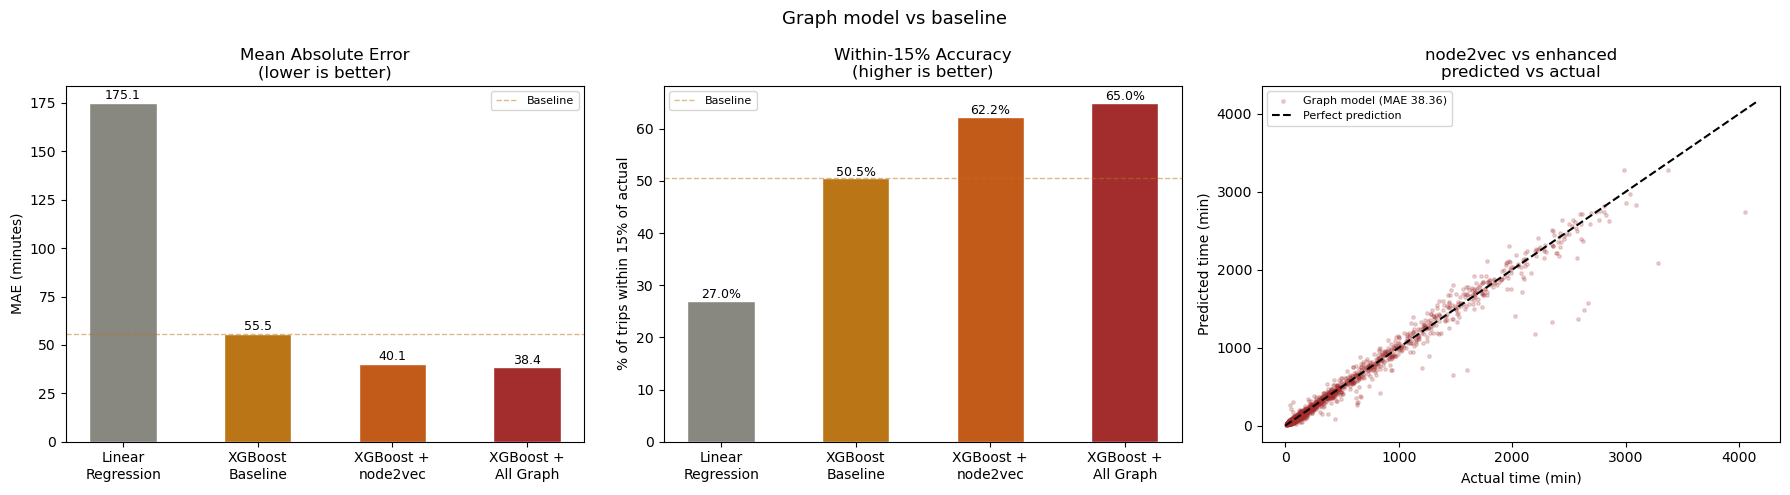


Graph advantage — measured:
  node2vec only  — MAE: 40.07  Within-15%: 62.23%
  Full enhanced  — MAE: 38.36  Within-15%: 64.99%

  vs baseline:
  MAE reduction     : 30.8%
  Within-15% gain   : +13.73 percentage points


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Chart 1: MAE comparison ────────────────────────────────────────────
models = ['Linear\nRegression', 'XGBoost\nBaseline',
          'XGBoost +\nnode2vec', 'XGBoost +\nAll Graph']
maes   = [175.12, 55.45, 40.07, 38.36]
colors = ['#888780', '#BA7517', '#C25A1A', '#A32D2D']

bars = axes[0].bar(models, maes, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel("MAE (minutes)")
axes[0].set_title("Mean Absolute Error\n(lower is better)")
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.1f}', ha='center', fontsize=9, fontweight='500')
axes[0].axhline(55.45, color='#BA7517', linestyle='--',
                linewidth=1, alpha=0.5, label='Baseline')
axes[0].legend(fontsize=8)

# ── Chart 2: Within 15% comparison ────────────────────────────────────
within15 = [27.00, 50.46, 62.23, 64.99]

bars2 = axes[1].bar(models, within15, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylabel("% of trips within 15% of actual")
axes[1].set_title("Within-15% Accuracy\n(higher is better)")
for bar, val in zip(bars2, within15):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='500')
axes[1].axhline(50.46, color='#BA7517', linestyle='--',
                linewidth=1, alpha=0.5, label='Baseline')
axes[1].legend(fontsize=8)

# ── Chart 3: Predicted vs actual — node2vec vs enhanced overlay ────────
sample = np.random.choice(len(y_test_raw), 2000, replace=False)

axes[2].scatter(y_test_raw.iloc[sample], y_pred_enh[sample],
                alpha=0.2, s=6, color='#A32D2D', label='Graph model (MAE 38.36)')
axes[2].plot([0, y_test_raw.max()], [0, y_test_raw.max()],
             color='black', linestyle='--', linewidth=1.5,
             label='Perfect prediction')
axes[2].set_xlabel("Actual time (min)")
axes[2].set_ylabel("Predicted time (min)")
axes[2].set_title("node2vec vs enhanced\npredicted vs actual")
axes[2].legend(fontsize=8)

plt.suptitle("Graph model vs baseline", fontsize=13)
plt.tight_layout()
plt.show()

print("\nGraph advantage — measured:")
print(f"  node2vec only  — MAE: 40.07  Within-15%: 62.23%")
print(f"  Full enhanced  — MAE: 38.36  Within-15%: 64.99%")
print(f"\n  vs baseline:")
print(f"  MAE reduction     : {((55.45 - 38.36)/55.45)*100:.1f}%")
print(f"  Within-15% gain   : +{64.19 - 50.46:.2f} percentage points")

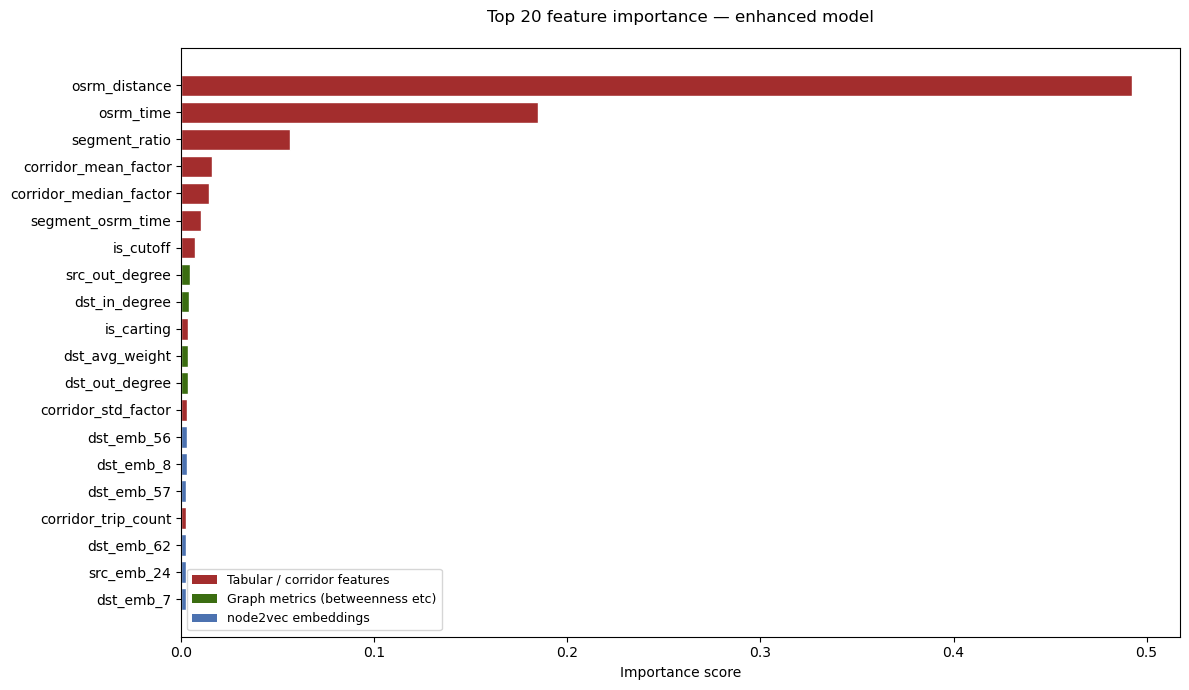

In [57]:
####
importance = pd.Series(
    xgb_enhanced.feature_importances_,
    index=X_train_enh.columns
).sort_values(ascending=False)

# Top 20 only — 90 features is too many to show all
top20 = importance.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#A32D2D' if 'corridor' in i or 'emb' not in i and 'src' not in i and 'dst' not in i
          else '#4C72B0' if 'emb' in i
          else '#3B6D11'
          for i in top20.index]

ax.barh(top20.index[::-1], top20.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title("Top 20 feature importance — enhanced model\n")
ax.set_xlabel("Importance score")

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(facecolor='#A32D2D', label='Tabular / corridor features'),
    Patch(facecolor='#3B6D11', label='Graph metrics (betweenness etc)'),
    Patch(facecolor='#4C72B0', label='node2vec embeddings'),
]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()


In [58]:
graph_model = {
    'model'            : xgb_enhanced,
    'features'         : X_train_enh.columns.tolist(),
    'n2v_model'        : model_n2v,
    'mae'              : 38.36,
    'within_15pct'     : 64.99,
    'description'      : 'XGBoost + node2vec embeddings + graph metrics + corridor features',
    'n2v_params'       : {
        'dimensions'  : 64,
        'walk_length' : 20,
        'num_walks'   : 200,
        'p'           : 1,
        'q'           : 2,
    },
    'feature_groups'   : {
        'tabular'    : 11,
        'graph_metrics' : 10,
        'corridor'   : 5,
        'embeddings' : 128,
        'total'      : 154,
    },
    'vs_baseline'      : {
        'mae_reduction_pct'    : 30.8,
        'within15_gain_pp'     : 13.73,
    }
}

model_path = f"{OUT_DIR}/graph_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(graph_model, f)